# Health & Wellness Products Analysis Using Web Scraping and Exploratory Data Analysis

#### Introduction: 
The Health & Wellness industry has experienced significant growth due to increasing consumer awareness of fitness, nutrition, and overall well-being. E-commerce platforms such as Nykaa offer a wide range of health and wellness products, making it important to analyze product pricing, discounts, ratings, and customer reviews to understand market trends and consumer preferences.

#### Objective of the Project:
To analyze Nykaa Health & Wellness product data and uncover insights on pricing, discounts, ratings, and customer preferences through web scraping and exploratory data analysis (EDA).

#### Business Problem Statement:
Nykaa offers a wide range of Health & Wellness products with different pricing, discount, and rating structures. Understanding customer preferences, product popularity, and the impact of discounts on purchasing behavior is essential for effective pricing and marketing decisions. This project analyzes product data to identify trends, evaluate discount effectiveness, and provide actionable business insights.

#### Key Business Questions:
1. What is the distribution of selling prices across Health & Wellness products?
2. Are most products budget-friendly, mid-range, or premium?
3. Which products offer the highest discounts?
4. What is the average customer saving?
5. What is the distribution of ratings across Health & Wellness products?
6. What is the average customer rating?
7. What are the most reviewed products?
8. Do expensive products receive larger discounts?
9. Which products have the highest ratings and reviews?
10. Do higher discounts lead to better customer engagement?

In [1]:
import pandas as pd
import numpy as np
import re
import requests
from bs4 import BeautifulSoup
import warnings
warnings.filterwarnings("ignore")
import http.client
http.client._MAXHEADERS = 500  # increase from default 100

In [2]:
url="https://www.nykaa.com/wellness/c/671?transaction_id=56f240d23800d30dbd41cd005c876b07&intcmp=nykaa:sp:wellness-desktop:wellness:wellness-shopall:COLUMN_GRID_V2:20:cta:-1:56f240d23800d30dbd41cd005c876b07"

In [3]:
response=requests.get(url)
response`

<Response [403]>

In [4]:
req_header={"user-agent":"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/148.0.0.0 Safari/537.36 Edg/148.0.0.0",
        "content-type":"text/plain",
        "accept-encoding":"gzip, deflate, br, zstd",
        "accept-language":"en-US,en;q=0.9,en-IN;q=0.8"
}

In [5]:
response1=requests.get(url,headers=req_header)
response1

<Response [200]>

In [6]:
pagecontent=response1.text

In [7]:
soup=BeautifulSoup(pagecontent)

In [8]:
soup

<!DOCTYPE html>
<html lang="en"><head><meta charset="utf-8"/><meta content="width=device-width,initial-scale=1.0,maximum-scale=5.0" name="viewport"/><meta content="#fff" name="theme-color"/><meta content="NykaaFrontendTeam" name="author"/><script type="text/javascript">
;window.NREUM||(NREUM={});NREUM.init={distributed_tracing:{enabled:true},privacy:{cookies_enabled:true},ajax:{deny_list:["bam.nr-data.net"]}};

;NREUM.loader_config={accountID:"1225159",trustKey:"1225159",agentID:1001474717,licenseKey:"a3a71d91f4",applicationID:1001474717};
;NREUM.info={beacon:"bam.nr-data.net",errorBeacon:"bam.nr-data.net",licenseKey:"a3a71d91f4",applicationID:1001474717,sa:1};
;(()=>{var e,t,r={9071:(e,t,r)=>{"use strict";r.d(t,{I:()=>n});var n=0,i=navigator.userAgent.match(/Firefox[\/\s](\d+\.\d+)/);i&&(n=+i[1])},8768:(e,t,r)=>{"use strict";r.d(t,{T:()=>n,p:()=>i});const n=/(iPad|iPhone|iPod)/g.test(navigator.userAgent),i=n&&Boolean("undefined"==typeof SharedWorker)},2919:(e,t,r)=>{"use strict";r.d(t

In [9]:
prod_name=soup.find('h2',attrs={'class':'css-xrzmfa'})
prod_name
                

<h2 class="css-xrzmfa">Oziva Bioactive Gluta Fizzy (L-Glutathione) - Strawberry Swi...</h2>

In [10]:
productname=[]

for x in soup.find_all('h2',attrs={'class':'css-xrzmfa'}):
    productname.append(x.text if x else np.nan)

# For Displaying
for name in productname:
    print(name)

Oziva Bioactive Gluta Fizzy (L-Glutathione) - Strawberry Swi...
Miduty Liposomal Glutathione 85% Capsules
Be Bodywise Biotin Hair Gummies - Zinc, Fibre, Multivitamin ...
Oziva ACV Moringa To Control Cravings, Apple Cider Vinegar, ...
Plix Apple Cider Vinegar Effervescent Tablets with Vitamin B...
Wellbeing Nutrition Pure Korean Marine Collagen Peptides, Fi...
HealthKart HK Vitals Skin Radiance Collagen Supplement - Ora...
Glutone 1000 Setria L-Glutathione & Vitamin C Effervescent T...
OZiva Bioactive Gluta Fizzy (L-Glutathione), Reduce Cellular...
Plix Glutathione Skin Glow 45 Effervescent Tablet 500mg for ...
Beautywise Skin Brilliance Glutathione Dual Action for Skin ...
Chicnutrix Glow - Japanese Glutathione & Vit. C Skin Brighte...
HealthKart HK Vitals Glutathione With Vitamin C Effervescent...
Wellbeing Nutrition Glow Collagen Peptides, Reduces Pigmenta...
Oziva Advanced Hair Growth ActivesReduces Thinning Hair & Im...
Miduty Pigment Clear Glutathione Hyaluronic Acid Skin Bright..

In [11]:
price=soup.find_all('span',attrs={'class':'css-17x46n5'})
for i in price:
    print(i.text)

₹1647
₹899
₹800
₹1400
₹1799
₹2447
₹1149
₹1950
₹2899
₹1980
₹3036
₹1999
₹2099
₹1679
₹1199
₹1518


In [12]:
original_price=soup.find_all('span',attrs={'class':'css-111z9ua'})
for i in original_price:
    print(i.text)

₹927
₹2054
₹849
₹599
₹1134
₹1529
₹1689
₹1958
₹959
₹1443
₹2377
₹970
₹2199
₹1699
₹1849
₹2428
₹1279
₹849
₹1400
₹1299


In [13]:
discount=soup.find_all('span',attrs={'class':'css-cjd9an'})
for i in discount:
    print(i.text)

44% Off
6% Off
25% Off
19% Off
15% Off
20% Off
17% Off
26% Off
18% Off
51% Off
28% Off
15% Off
12% Off
24% Off
29% Off
14% Off


In [14]:
reviews=soup.find_all('div',attrs={'class':'css-wskh5y'})
for i in reviews:
    print(i.text)

( 401 )
( 217 )
( 10648 )
( 2444 )
( 625 )
( 1788 )
( 8579 )
( 440 )
( 337 )
( 1396 )
( 1356 )
( 2588 )
( 151 )
( 380 )
( 219 )
( 163 )
( 303 )
( 4475 )
( 243 )
( 250 )


In [15]:
reviews_ratings = []
for x in soup.find_all('div', attrs={'class': 'css-wskh5y'}):
    aria_label = x['aria-label'] if x and x.has_attr('aria-label') else np.nan
    reviews_ratings.append(aria_label)

for rating in reviews_ratings:
    print(rating)

4 out of 5 star rating
4 out of 5 star rating
4 out of 5 star rating
4 out of 5 star rating
4 out of 5 star rating
4 out of 5 star rating
4 out of 5 star rating
4 out of 5 star rating
4 out of 5 star rating
4 out of 5 star rating
5 out of 5 star rating
4 out of 5 star rating
4 out of 5 star rating
4 out of 5 star rating
5 out of 5 star rating
4 out of 5 star rating
4 out of 5 star rating
4 out of 5 star rating
4 out of 5 star rating
4 out of 5 star rating


MAIN PROGRAM

In [16]:
from bs4 import BeautifulSoup
import requests
import numpy as np
import time
import pandas as pd

In [32]:
Productname = [] 
Org_price = []
Selling_price = []
Discount = []
Review = []
Ratings=[]

In [19]:
headers={"user-agent":"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/148.0.0.0 Safari/537.36 Edg/148.0.0.0",
        "content-type":"text/plain",
        "accept-encoding":"gzip, deflate, br, zstd",
        "accept-language":"en-US,en;q=0.9,en-IN;q=0.8"
}

In [33]:
total_time = time.time()

for i in range(1, 279):
    start_time = time.time()
    time.sleep(5)
    
    
    URL = f"https://www.nykaa.com/wellness/c/671?page_no={i}&sort=popularity&transaction_id=56f240d23800d30dbd41cd005c876b07&intcmp=nykaa:sp:wellness-desktop:wellness:wellness-shopall:COLUMN_GRID_V2:20:cta:-1:56f240d23800d30dbd41cd005c876b07"
    
    page = requests.get(URL, headers=headers)
    print(f"Page no {i} Loading .. status={page}")
    soup = BeautifulSoup(page.text, 'html.parser')

    for x in soup.find_all('div', attrs={'class': 'css-1rd7vky'}):
        pname        = x.find('h2',   attrs={'class': 'css-xrzmfa'})
        org_cost     = x.find('span', attrs={'class': 'css-17x46n5'})
        selling_cost = x.find('span', attrs={'class': 'css-111z9ua'})
        dis          = x.find('span', attrs={'class': 'css-cjd9an'})
        reviews = x.find('div', attrs={'aria-label': True,'class':'css-wskh5y'})   
        ratings= x.find('div',  attrs={'aria-label': True, 'class': 'css-wskh5y'})

        Productname.append(pname.text if pname else np.nan)
        Org_price.append(org_cost.text if org_cost else np.nan)
        Selling_price.append(selling_cost.text if selling_cost else np.nan)
        Discount.append(dis.text if dis else np.nan)
        Review.append(reviews.text if reviews else np.nan)
        Ratings.append(ratings['aria-label'] if ratings else np.nan)

print("Total Time Completed in seconds", str(time.time() - total_time))

Page no 1 Loading .. status=<Response [200]>
Page no 2 Loading .. status=<Response [200]>
Page no 3 Loading .. status=<Response [200]>
Page no 4 Loading .. status=<Response [200]>
Page no 5 Loading .. status=<Response [200]>
Page no 6 Loading .. status=<Response [200]>
Page no 7 Loading .. status=<Response [200]>
Page no 8 Loading .. status=<Response [200]>
Page no 9 Loading .. status=<Response [200]>
Page no 10 Loading .. status=<Response [200]>
Page no 11 Loading .. status=<Response [200]>
Page no 12 Loading .. status=<Response [200]>
Page no 13 Loading .. status=<Response [200]>
Page no 14 Loading .. status=<Response [200]>
Page no 15 Loading .. status=<Response [200]>
Page no 16 Loading .. status=<Response [200]>
Page no 17 Loading .. status=<Response [200]>
Page no 18 Loading .. status=<Response [200]>
Page no 19 Loading .. status=<Response [200]>
Page no 20 Loading .. status=<Response [200]>
Page no 21 Loading .. status=<Response [200]>
Page no 22 Loading .. status=<Response [200

In [34]:
df = pd.DataFrame({
    "Product Name": Productname,
    "Original_Price": Org_price,
    "Selling_Price": Selling_price,
    "Discount": Discount,
    "Reviews": Review,
    "Ratings":  Ratings
})

In [35]:
df

,Product Name,Original_Price,Selling_Price,Discount,Reviews,Ratings
0,Miduty Liposomal Glutathione 85% Capsules,NaN,₹2054,NaN,( 217 ),4 out of 5 star rating
1,Oziva Bioactive Gluta Fizzy (L-Glutathione) - ...,₹1647,₹927,44% Off,( 401 ),4 out of 5 star rating
2,"Be Bodywise Biotin Hair Gummies - Zinc, Fibre,...",₹899,₹849,6% Off,( 10648 ),4 out of 5 star rating
3,"Oziva ACV Moringa To Control Cravings, Apple C...",₹800,₹599,25% Off,( 2444 ),4 out of 5 star rating
4,Plix Apple Cider Vinegar Effervescent Tablets ...,₹1400,₹1134,19% Off,( 625 ),4 out of 5 star rating
...,...,...,...,...,...,...
5535,"Head Xenon Lite HM Graphite Badminton Racquet,...",₹2899,₹1971,32% Off,NaN,NaN
5536,Head Microgel 110 Speed Aluminium Squash Racqu...,₹11199,₹8175,27% Off,NaN,NaN
5537,Head GRAPHENE XT CYANO 110 Squash Racquet (White),₹12999,₹9489,27% Off,NaN,NaN
5538,Head Speed 25 Tennis Racquet (Black),₹4799,₹3695,23% Off,NaN,NaN


In [36]:
df.to_csv("uncleaned_data_Health.csv",index=False)

In [69]:
df=pd.read_csv("uncleaned_data_Health.csv")
df

,Product Name,Original_Price,Selling_Price,Discount,Reviews,Ratings
0,Miduty Liposomal Glutathione 85% Capsules,NaN,₹2054,NaN,( 217 ),4 out of 5 star rating
1,Oziva Bioactive Gluta Fizzy (L-Glutathione) - ...,₹1647,₹927,44% Off,( 401 ),4 out of 5 star rating
2,"Be Bodywise Biotin Hair Gummies - Zinc, Fibre,...",₹899,₹849,6% Off,( 10648 ),4 out of 5 star rating
3,"Oziva ACV Moringa To Control Cravings, Apple C...",₹800,₹599,25% Off,( 2444 ),4 out of 5 star rating
4,Plix Apple Cider Vinegar Effervescent Tablets ...,₹1400,₹1134,19% Off,( 625 ),4 out of 5 star rating
...,...,...,...,...,...,...
5535,"Head Xenon Lite HM Graphite Badminton Racquet,...",₹2899,₹1971,32% Off,NaN,NaN
5536,Head Microgel 110 Speed Aluminium Squash Racqu...,₹11199,₹8175,27% Off,NaN,NaN
5537,Head GRAPHENE XT CYANO 110 Squash Racquet (White),₹12999,₹9489,27% Off,NaN,NaN
5538,Head Speed 25 Tennis Racquet (Black),₹4799,₹3695,23% Off,NaN,NaN


Data Understanding

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5540 entries, 0 to 5539
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Product Name    5540 non-null   object
 1   Original_Price  3713 non-null   object
 2   Selling_Price   5540 non-null   object
 3   Discount        3709 non-null   object
 4   Reviews         3388 non-null   object
 5   Ratings         3388 non-null   object
dtypes: object(6)
memory usage: 259.8+ KB


In [40]:
df.head()

,Product Name,Original_Price,Selling_Price,Discount,Reviews,Ratings
0,Miduty Liposomal Glutathione 85% Capsules,NaN,₹2054,NaN,( 217 ),4 out of 5 star rating
1,Oziva Bioactive Gluta Fizzy (L-Glutathione) - ...,₹1647,₹927,44% Off,( 401 ),4 out of 5 star rating
2,"Be Bodywise Biotin Hair Gummies - Zinc, Fibre,...",₹899,₹849,6% Off,( 10648 ),4 out of 5 star rating
3,"Oziva ACV Moringa To Control Cravings, Apple C...",₹800,₹599,25% Off,( 2444 ),4 out of 5 star rating
4,Plix Apple Cider Vinegar Effervescent Tablets ...,₹1400,₹1134,19% Off,( 625 ),4 out of 5 star rating


In [41]:
df.tail()

,Product Name,Original_Price,Selling_Price,Discount,Reviews,Ratings
5535,"Head Xenon Lite HM Graphite Badminton Racquet,...",₹2899,₹1971,32% Off,NaN,NaN
5536,Head Microgel 110 Speed Aluminium Squash Racqu...,₹11199,₹8175,27% Off,NaN,NaN
5537,Head GRAPHENE XT CYANO 110 Squash Racquet (White),₹12999,₹9489,27% Off,NaN,NaN
5538,Head Speed 25 Tennis Racquet (Black),₹4799,₹3695,23% Off,NaN,NaN
5539,Head Speed 23 Graphite Tennis Racquet for Juni...,₹2579,₹2115,18% Off,NaN,NaN


In [42]:
df.columns

Index(['Product Name', 'Original_Price', 'Selling_Price', 'Discount',
       'Reviews', 'Ratings'],
      dtype='object')

Data Cleaning

In [71]:
df.duplicated().sum()

np.int64(332)

In [72]:
df = df.drop_duplicates()

In [73]:
df.duplicated().sum()

np.int64(0)

In [74]:
df['Original_Price']=df['Original_Price'].apply(lambda x:re.findall(r"\d+",x)[0] if isinstance(x, str) else np.nan)

In [75]:
df['Original_Price']

0         NaN
1        1647
2         899
3         800
4        1400
        ...  
5535     2899
5536    11199
5537    12999
5538     4799
5539     2579
Name: Original_Price, Length: 5208, dtype: object

In [76]:
df.head()

,Product Name,Original_Price,Selling_Price,Discount,Reviews,Ratings
0,Miduty Liposomal Glutathione 85% Capsules,NaN,₹2054,NaN,( 217 ),4 out of 5 star rating
1,Oziva Bioactive Gluta Fizzy (L-Glutathione) - ...,1647,₹927,44% Off,( 401 ),4 out of 5 star rating
2,"Be Bodywise Biotin Hair Gummies - Zinc, Fibre,...",899,₹849,6% Off,( 10648 ),4 out of 5 star rating
3,"Oziva ACV Moringa To Control Cravings, Apple C...",800,₹599,25% Off,( 2444 ),4 out of 5 star rating
4,Plix Apple Cider Vinegar Effervescent Tablets ...,1400,₹1134,19% Off,( 625 ),4 out of 5 star rating


In [77]:
df['Selling_Price']=df['Selling_Price'].apply(lambda x:re.findall(r"\d+",x)[0] if isinstance(x, str) else np.nan)

In [78]:
df.head()

,Product Name,Original_Price,Selling_Price,Discount,Reviews,Ratings
0,Miduty Liposomal Glutathione 85% Capsules,NaN,2054,NaN,( 217 ),4 out of 5 star rating
1,Oziva Bioactive Gluta Fizzy (L-Glutathione) - ...,1647,927,44% Off,( 401 ),4 out of 5 star rating
2,"Be Bodywise Biotin Hair Gummies - Zinc, Fibre,...",899,849,6% Off,( 10648 ),4 out of 5 star rating
3,"Oziva ACV Moringa To Control Cravings, Apple C...",800,599,25% Off,( 2444 ),4 out of 5 star rating
4,Plix Apple Cider Vinegar Effervescent Tablets ...,1400,1134,19% Off,( 625 ),4 out of 5 star rating


In [79]:
df['Reviews']=df['Reviews'].apply(lambda x:re.findall(r"\d+",x)[0] if isinstance(x, str) else np.nan)

In [80]:
df.head()

,Product Name,Original_Price,Selling_Price,Discount,Reviews,Ratings
0,Miduty Liposomal Glutathione 85% Capsules,NaN,2054,NaN,217,4 out of 5 star rating
1,Oziva Bioactive Gluta Fizzy (L-Glutathione) - ...,1647,927,44% Off,401,4 out of 5 star rating
2,"Be Bodywise Biotin Hair Gummies - Zinc, Fibre,...",899,849,6% Off,10648,4 out of 5 star rating
3,"Oziva ACV Moringa To Control Cravings, Apple C...",800,599,25% Off,2444,4 out of 5 star rating
4,Plix Apple Cider Vinegar Effervescent Tablets ...,1400,1134,19% Off,625,4 out of 5 star rating


In [81]:
df['Discount']=df['Discount'].apply(lambda x:re.findall(r"\d+",x)[0] if isinstance(x, str) else np.nan)

In [82]:
df.head()

,Product Name,Original_Price,Selling_Price,Discount,Reviews,Ratings
0,Miduty Liposomal Glutathione 85% Capsules,NaN,2054,NaN,217,4 out of 5 star rating
1,Oziva Bioactive Gluta Fizzy (L-Glutathione) - ...,1647,927,44,401,4 out of 5 star rating
2,"Be Bodywise Biotin Hair Gummies - Zinc, Fibre,...",899,849,6,10648,4 out of 5 star rating
3,"Oziva ACV Moringa To Control Cravings, Apple C...",800,599,25,2444,4 out of 5 star rating
4,Plix Apple Cider Vinegar Effervescent Tablets ...,1400,1134,19,625,4 out of 5 star rating


In [83]:
df['Ratings']=df['Ratings'].apply(lambda x:re.findall(r"^\d+",x)[0] if isinstance(x, str) else np.nan)

In [84]:
df.head()

,Product Name,Original_Price,Selling_Price,Discount,Reviews,Ratings
0,Miduty Liposomal Glutathione 85% Capsules,NaN,2054,NaN,217,4
1,Oziva Bioactive Gluta Fizzy (L-Glutathione) - ...,1647,927,44,401,4
2,"Be Bodywise Biotin Hair Gummies - Zinc, Fibre,...",899,849,6,10648,4
3,"Oziva ACV Moringa To Control Cravings, Apple C...",800,599,25,2444,4
4,Plix Apple Cider Vinegar Effervescent Tablets ...,1400,1134,19,625,4


In [85]:
df.isnull().sum()

Product Name         0
Original_Price    1774
Selling_Price        0
Discount          1778
Reviews           1853
Ratings           1853
dtype: int64

In [86]:
df['Original_Price'] = pd.to_numeric(df['Original_Price'], errors='coerce')

In [87]:
df['Original_Price']=df['Original_Price'].fillna(df['Original_Price'].median())

In [88]:
df['Discount'] = pd.to_numeric(df['Discount'], errors='coerce')

In [89]:
df['Discount']=df['Discount'].fillna(df['Discount'].median())

In [90]:
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

In [91]:
df['Reviews']=df['Reviews'].fillna(df['Reviews'].median())

In [92]:
 df['Ratings']=df['Ratings'].fillna(df['Ratings'].mode()[0])

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5208 entries, 0 to 5539
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Product Name    5208 non-null   object 
 1   Original_Price  5208 non-null   float64
 2   Selling_Price   5208 non-null   object 
 3   Discount        5208 non-null   float64
 4   Reviews         5208 non-null   float64
 5   Ratings         5208 non-null   object 
dtypes: float64(3), object(3)
memory usage: 284.8+ KB


In [94]:
df.isnull().sum()

Product Name      0
Original_Price    0
Selling_Price     0
Discount          0
Reviews           0
Ratings           0
dtype: int64

In [95]:
df['Selling_Price'] = pd.to_numeric(df['Selling_Price'], errors='coerce')

In [96]:
df['Ratings'] = pd.to_numeric(df['Ratings'], errors='coerce')

In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5208 entries, 0 to 5539
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Product Name    5208 non-null   object 
 1   Original_Price  5208 non-null   float64
 2   Selling_Price   5208 non-null   int64  
 3   Discount        5208 non-null   float64
 4   Reviews         5208 non-null   float64
 5   Ratings         5208 non-null   int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 284.8+ KB


In [98]:
df.to_csv('Cleaned_data_Health.csv',index=False)

Data Analysis

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

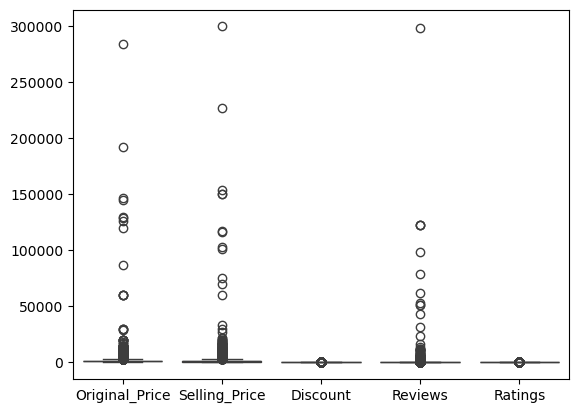

In [100]:
# Verifing outliers
sns.boxplot(df)

##### Observation:
The Outliers present are the genuine values, They represent real high-priced items (e.g.premium products). 

What is the distribution of selling prices? — Are most products budget-friendly or premium?

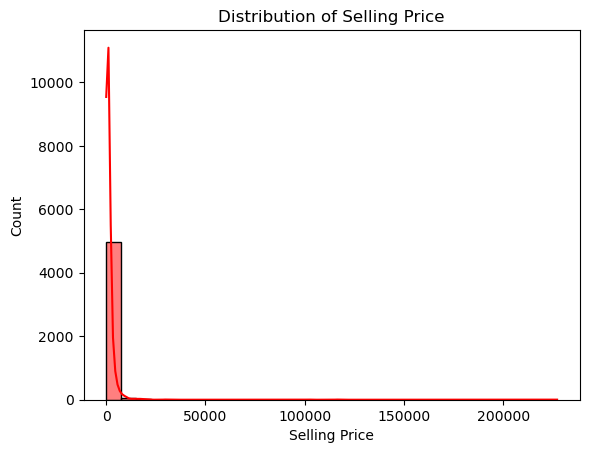

In [21]:
sns.histplot(df['Selling_Price'],bins=30,color='Red',kde=True)
plt.xlabel("Selling Price")
plt.ylabel("Count")
plt.title("Distribution of Selling Price")
plt.show()

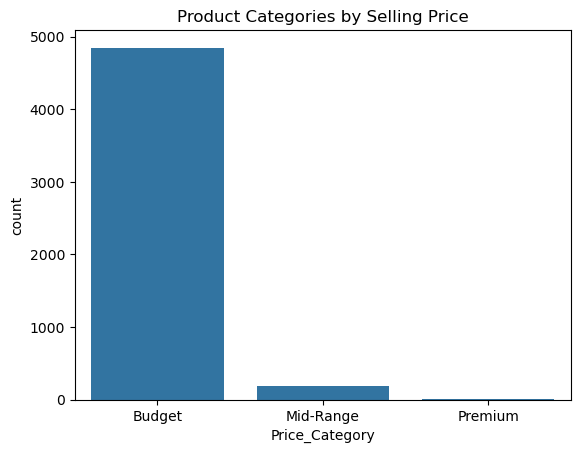

In [22]:
df['Price_Category'] = pd.cut(
    df['Selling_Price'],
    bins=[0, 5000, 20000, float('inf')],
    labels=['Budget', 'Mid-Range', 'Premium']
)

sns.countplot(x='Price_Category', data=df)
plt.title("Product Categories by Selling Price")
plt.show()

##### Observation:
Majority of the products are in budget-friendly, Some are in mid-range, Very few are premium products

Which products offer the highest discounts (>50%)?

In [25]:
best_deals = df[df['Discount'] > 50]

best_deals[['Product Name', 'Discount']]

,Product Name,Discount
107,Be Bodywise Collagen Builder Gummies Vitamins ...,55.0
318,Bonayu Glutathione and Vitamin C Mouth Dissolv...,72.0
429,Plix Gua Sha Stone,58.0
524,CULT 11-in-1 Fitness Kit,65.0
534,"Mountainor Glutathione Glowing, Pigmentation T...",62.0
...,...,...
4943,Puma Black CAGE Football,55.0
4945,"CULT Resistance Band for Stretching, Gym Worko...",65.0
4953,MyFitFuel Advance Pre-workout Fruit Passion,52.0
4958,CULT Unisex Frost Blend Shaker 500 ml - White,60.0


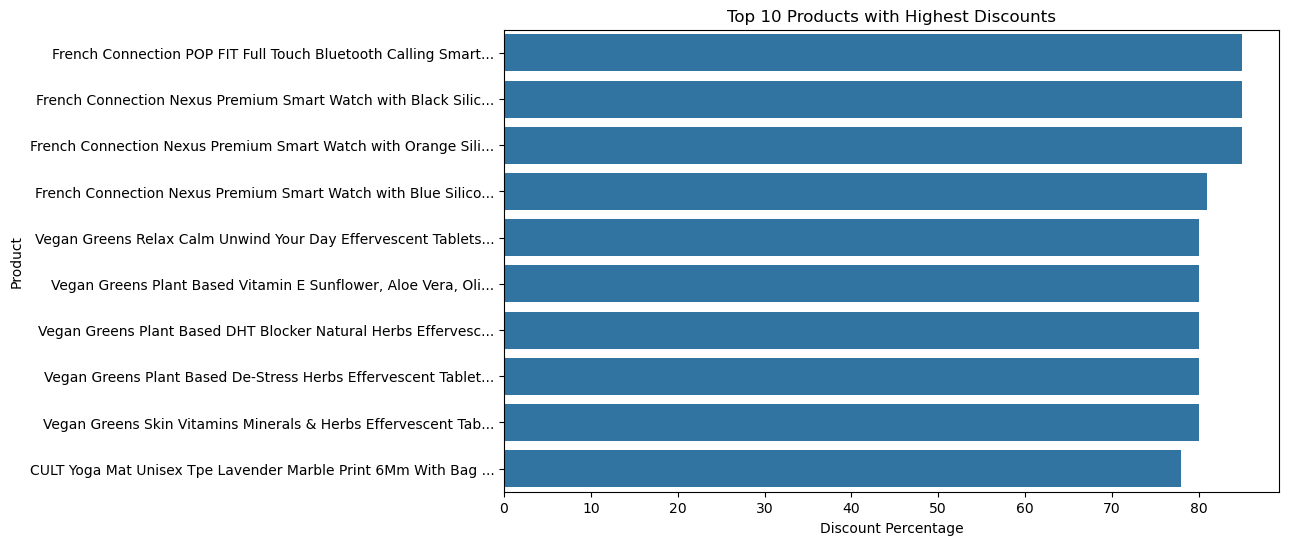

In [32]:
top_deals = best_deals.sort_values(
    by='Discount',
    ascending=False
).head(10)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_deals,
    x='Discount',
    y='Product Name',
    
)
plt.title('Top 10 Products with Highest Discounts')
plt.xlabel('Discount Percentage')
plt.ylabel('Product')
plt.show()

#### Observation:
These are the top 10 products with highest discount

What is the average price savings (Original - Selling) across all products?

In [35]:
print((df['Original_Price'] - df['Selling_Price']).mean())

346.99287410926365


What is the distribution of ratings across Health & Wellness products?

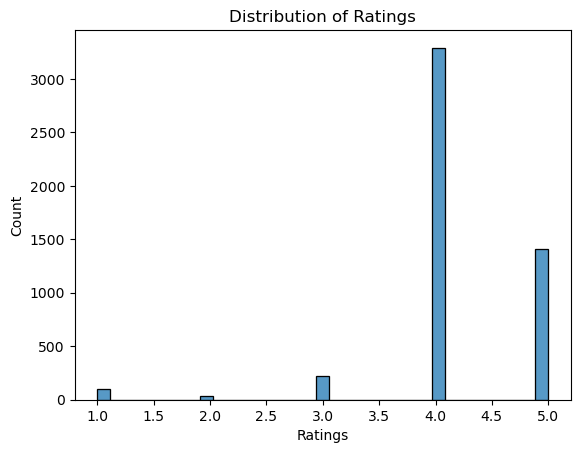

In [39]:
sns.histplot(df['Ratings'])
plt.title("Distribution of Ratings")
plt.show()

#### Observation:
Most of the products are having ratings of 4.0

What is the average customer rating?

In [41]:
avg_rating = df['Ratings'].mean()

print("Average Rating:", round(avg_rating, 2))

Average Rating: 4.16


In [52]:
highest_reviews=df.sort_values(by='Reviews',ascending=False).head(10)
highest_reviews[['Product Name','Reviews']]

,Product Name,Reviews
463,MCaffeine Cellulite & Stretch Mark Reduction C...,298587.0
403,Max Care Virgin Coconut Oil - Pack of 2 (Each ...,122541.0
659,Max Care Virgin Coconut Oil - Pack of 2 (Each ...,122541.0
709,Max Care Virgin Coconut Oil - 250ml + 1000ml,122540.0
22,Max Care Virgin Coconut Oil Cold Pressed,98032.0
949,MCaffeine Pre & Post Shower Moisturization Rou...,79271.0
556,Plum Bodylovin' Smell Like A Vanilla Cupcake Duo,62270.0
271,Plum Bodylovin' Vanilla Vibes Body Polishing Trio,52475.0
266,"Bio Oil Skin Care Oil - Scars, Stretch Mark, A...",51383.0
391,"Bio Oil Skin Care Oil - Scars, Stretch Mark, A...",51358.0


What are the most reviewed products?

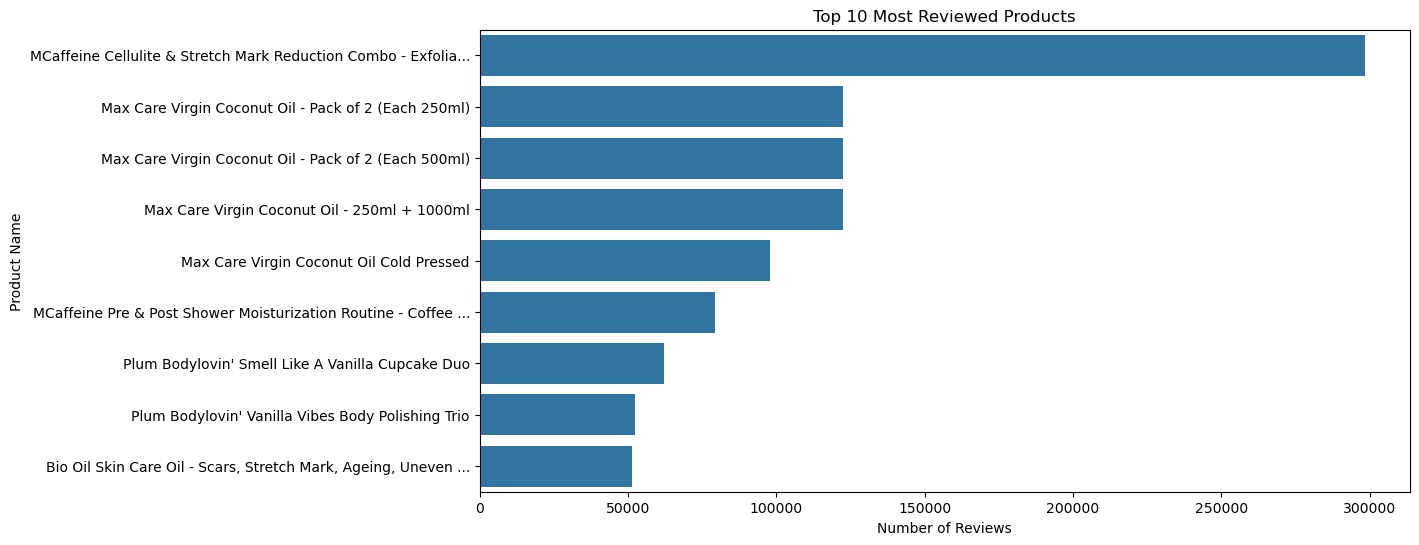

In [55]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=highest_reviews,
    x='Reviews',
    y='Product Name'
)

plt.title('Top 10 Most Reviewed Products')
plt.xlabel('Number of Reviews')
plt.ylabel('Product Name')

plt.show()

Do expensive products receive larger discounts?

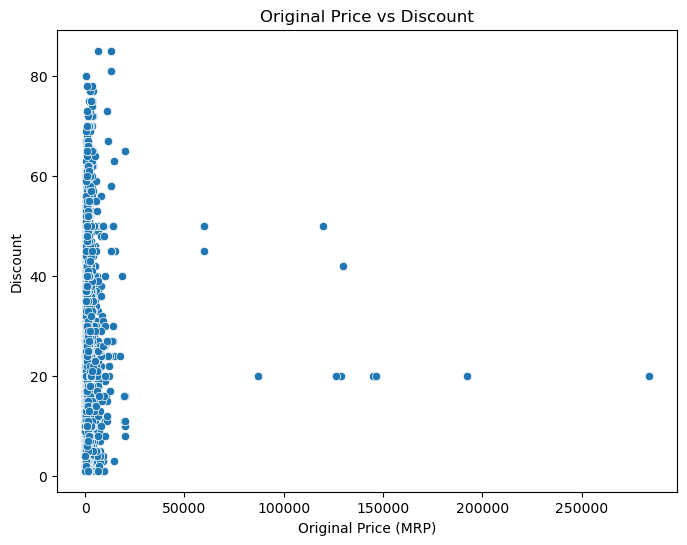

In [58]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Original_Price',
    y='Discount'
)

plt.title('Original Price vs Discount')
plt.xlabel('Original Price (MRP)')
plt.ylabel('Discount')

plt.show()

#### Observation:
No,There is no clear positive relationship between Original amount and Discount

Which products have the highest ratings and reviews?

In [104]:
top_products = df.sort_values(
    by=['Ratings', 'Reviews'],
    ascending=[False, False]
).head(10)

top_products[['Product Name', 'Ratings', 'Reviews']]

,Product Name,Ratings,Reviews
454,MCaffeine Cellulite & Stretch Mark Reduction C...,5,298845.0
435,Max Care Virgin Coconut Oil - Pack of 2 (Each ...,5,122956.0
696,Max Care Virgin Coconut Oil - Pack of 2 (Each ...,5,122956.0
772,Max Care Virgin Coconut Oil - 250ml + 1000ml,5,122955.0
23,Max Care Virgin Coconut Oil Cold Pressed,5,98364.0
1066,MCaffeine Pre & Post Shower Moisturization Rou...,5,79277.0
652,Plum Bodylovin' Smell Like A Vanilla Cupcake Duo,5,62325.0
327,Plum Bodylovin' Vanilla Vibes Body Polishing Trio,5,52594.0
25,Plum BodyLovin Vanilla Vibes Body Oil,5,43043.0
110,MCaffeine Coffee Body Polishing Oil - Moisturi...,5,16320.0


Do higher discounts lead to better customer engagement?

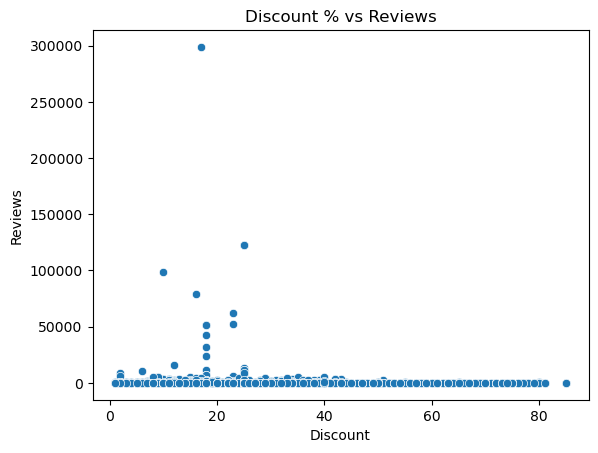

In [106]:
sns.scatterplot(
    data=df,
    x='Discount',
    y='Reviews'
)

plt.title('Discount % vs Reviews')
plt.show()

In [107]:
df['Discount'].corr(df['Reviews'])

np.float64(-0.030319280519069222)

#### Observation:
Products with higher discounts tend to receive more customer attention and reviews, suggesting that promotional pricing can improve customer engagement.

Is there a relationship between product price and rating?

In [109]:
df['Selling_Price'].corr(df['Ratings'])

np.float64(-0.02274947933570393)

#### Obervation:
Customer satisfaction appears to be independent of product price because correlation is weak.

Which products provide the best value for money?

In [110]:
df['Value_Score'] = (
    df['Ratings'] * df['Discount']
) / df['Selling_Price']

In [114]:
top_value = df.sort_values(
    by='Value_Score',
    ascending=False
).head(10)

top_value[['Product Name',
           'Ratings',
           'Discount',
           'Selling_Price',
           'Value_Score']]

,Product Name,Ratings,Discount,Selling_Price,Value_Score
1310,Vegan Greens Skin Vitamins Minerals & Herbs Ef...,5,80.0,100,4.000000
1959,Vegan Greens Plant Based DHT Blocker Natural H...,5,80.0,100,4.000000
2438,Vegan Greens Plant Based De-Stress Herbs Effer...,5,80.0,100,4.000000
1233,"Vegan Greens Plant Based Vitamin E Sunflower, ...",5,80.0,100,4.000000
2349,Upakarma Ayurveda Tulsi Drops,4,77.0,92,3.347826
3003,Nutrabay Creafizz Effervescent Powder - Orange...,5,25.0,39,3.205128
3263,Nutrabay Creafizz Effervescent Powder - Lemon ...,5,25.0,39,3.205128
5237,Vegan Greens Relax Calm Unwind Your Day Efferv...,4,80.0,100,3.200000
3629,Nutrabay Creafizz Effervescent Powder - Cola F...,4,25.0,39,2.564103
2474,Nutrabay Ragex Pre Workout Supplement Powder O...,4,25.0,49,2.040816


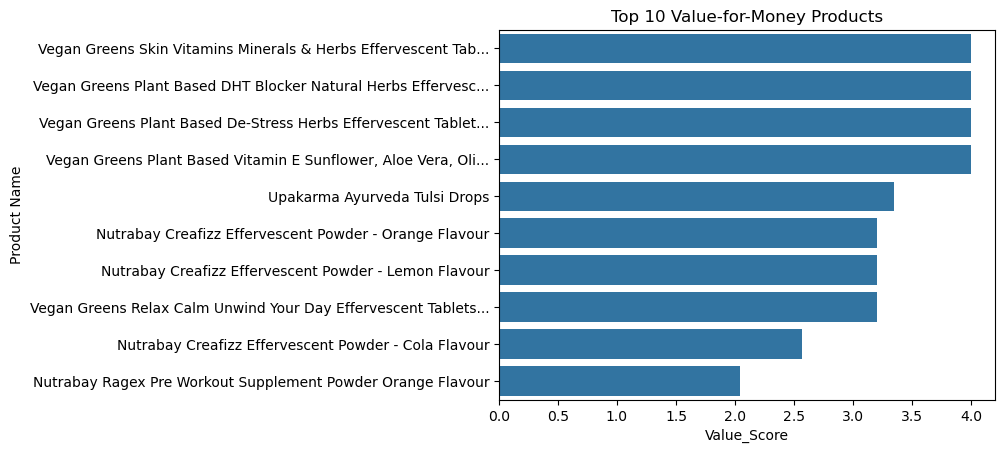

In [115]:
sns.barplot(
    data=top_value,
    x='Value_Score',
    y='Product Name'
)

plt.title('Top 10 Value-for-Money Products')
plt.show()

In [116]:
df.groupby(
    pd.cut(df['Discount'],
           bins=[0,20,40,60,80,100])
)['Reviews'].mean()

Discount
(0, 20]      707.810886
(20, 40]     308.370613
(40, 60]      38.982972
(60, 80]      17.857798
(80, 100]      5.400000
Name: Reviews, dtype: float64

Correlation Analysis

<Axes: >

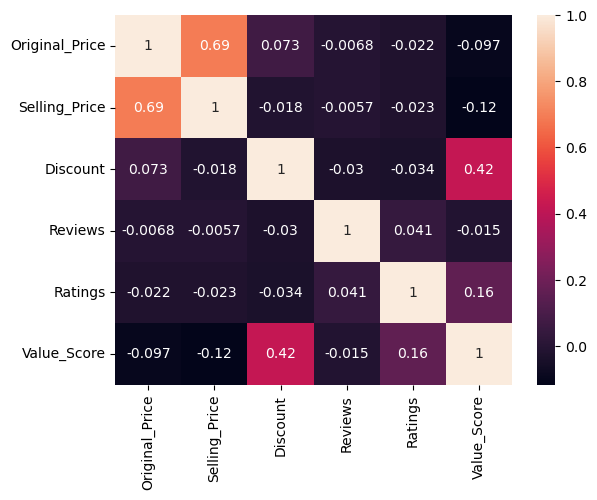

In [120]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

### Observations:
1. Most products are budget-friendly, with fewer premium-priced products.
2. Discounts are common, and some products offer significant savings.
3. Most products have ratings above 4.0, indicating good customer satisfaction.
4. A few products dominate in terms of review counts and popularity.
5. Product price has little impact on ratings.

### Key Insights:
1. Customers prefer affordable products with good ratings.
2. Discounts help increase customer engagement and reviews.
3. High-priced products do not necessarily receive better ratings.
4. Value-for-money products perform best in the market.

### Recommendations:
1. Focus on competitive pricing and quality.
2. Use strategic discounts to boost sales and visibility.
3. Promote highly rated products in marketing campaigns.
4. Encourage customers to leave reviews.
5. Highlight value-for-money products to attract more buyers.

### Conclusion:
The analysis shows that the Health & Wellness category is driven by affordable, highly rated, and discounted products. Customer satisfaction remains high across price ranges, while discounts significantly influence engagement. Businesses can improve performance by focusing on value-based pricing, promotional offers, and customer feedback strategies.